# V11 — Neural hierarchical chess player modeling

Objectif : tester deux extensions neuronales de V10.

## Proposition A — V11-A : neural game embedding + LightGBM
```text
moves d'une partie -> DeepSets/Attention -> game_embedding
game_embedding + game-level features -> LightGBM -> Elo local de la partie
Elo locaux de N parties -> agrégation/calibration -> Elo joueur
```

## Proposition B — V11-B : modèle hiérarchique end-to-end
```text
moves -> game embeddings -> player embedding -> Elo joueur
```

Méthodologie intégrée : split stratifié par Elo, exclusion des colonnes de leakage/date, tests sur `N = [3, 5, 10, 30]`, pondération des parties, calibration post-hoc et analyse par buckets Elo.


In [1]:
# ============================================================
# 0. Imports & configuration
# ============================================================
from pathlib import Path
import os, re, math, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from lightgbm import LGBMRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

BASE_DIR = Path("/content/drive/MyDrive/Data_Pmind_700-30")  # à adapter si besoin
CACHE_DIR = Path("/content/_pmind_v11_cache") if Path("/content").exists() else Path("./_pmind_v11_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CADENCES = ["bullet", "blitz", "rapid"]
N_VALUES = [3, 5, 10, 30]
SEEDS = [0, 1, 2]  # mets [0,1,2,3,4] si tu as le temps

FAST_DEBUG = False
if FAST_DEBUG:
    N_VALUES = [3]
    SEEDS = [0]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_MOVES_PER_GAME = 80
MAX_GAMES_PER_PLAYER = 30
GAME_EMB_DIM = 48
PLAYER_EMB_DIM = 64
BATCH_SIZE_GAMES = 128
BATCH_SIZE_PLAYERS = 64
NEURAL_EPOCHS_GAME = 25
NEURAL_EPOCHS_PLAYER = 35
PATIENCE = 6
LR = 1e-3
WEIGHT_DECAY = 1e-4

FORBIDDEN_PATTERNS = [
    "opponent", "opp_", "elo_diff", "rating_diff", "avg_opponent",
    "white_elo", "black_elo", "opponent_elo", "game_month",
    "created_at", "timestamp", "utc", "date", "month"
]

print("DEVICE:", DEVICE)
print("BASE_DIR:", BASE_DIR)
print("CACHE_DIR:", CACHE_DIR)


DEVICE: cpu
BASE_DIR: /content/drive/MyDrive/Data_Pmind_700-30
CACHE_DIR: /content/_pmind_v11_cache


In [2]:
# ============================================================
# 1. Fonctions utilitaires générales
# ============================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "bias": float(np.mean(y_pred - y_true)),
    }

def find_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def infer_player_col(df):
    candidates = ["player_id", "target_username", "username", "player", "user_id", "lichess_id", "name"]
    c = find_first_existing_col(df, candidates)
    if c is None:
        raise ValueError(f"Impossible d'inférer la colonne joueur. Colonnes disponibles : {df.columns.tolist()[:80]}")
    return c

def infer_game_col(df):
    candidates = ["game_id", "id_game", "game", "id", "lichess_game_id"]
    c = find_first_existing_col(df, candidates)
    if c is None:
        raise ValueError(f"Impossible d'inférer la colonne partie. Colonnes disponibles : {df.columns.tolist()[:80]}")
    return c

def infer_target_col(df):
    preferred = ["elo", "target_elo", "player_elo", "rating", "target_rating", "current_elo"]
    for c in preferred:
        if c in df.columns and "opponent" not in c.lower() and "opp" not in c.lower():
            return c
    for c in df.columns:
        lc = c.lower()
        if ("elo" in lc or "rating" in lc) and "opponent" not in lc and "opp" not in lc and "diff" not in lc:
            return c
    raise ValueError("Impossible d'inférer la cible Elo.")

def safe_numeric_cols(df, exclude_cols=None, forbidden_patterns=None):
    exclude_cols = set(exclude_cols or [])
    forbidden_patterns = forbidden_patterns or FORBIDDEN_PATTERNS
    cols = []
    for c in df.columns:
        lc = c.lower()
        if c in exclude_cols:
            continue
        if any(p in lc for p in forbidden_patterns):
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

def clean_inf_nan(df):
    return df.replace([np.inf, -np.inf], np.nan)

def add_elo_buckets(df, y_col="elo", n_bins=5):
    df = df.copy()
    try:
        df["elo_bucket"] = pd.qcut(df[y_col], q=n_bins, labels=False, duplicates="drop")
    except Exception:
        df["elo_bucket"] = pd.cut(df[y_col], bins=n_bins, labels=False, duplicates="drop")
    return df


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# ============================================================
# 2. Chargement flexible des données — VERSION CORRIGÉE
# ============================================================

def find_csv_for_role(cadence_dir: Path, role: str):
    files = list(cadence_dir.glob("*.csv")) + list(cadence_dir.glob("**/*.csv"))
    role = role.lower()

    patterns = {
        "moves": ["move", "moves", "coups"],
        "games": ["game", "games", "parties"],
        "players": ["player", "players", "joueurs"],
        "summary": ["summary", "resume", "summaries"],
    }[role]

    candidates = []

    for f in files:
        name = f.name.lower()
        if any(p in name for p in patterns):
            candidates.append(f)

    if not candidates:
        return None

    if role == "games":
        candidates = [
            f for f in candidates
            if "move" not in f.name.lower()
        ] or candidates

    return sorted(candidates, key=lambda x: len(str(x)))[0]


def resolve_cadence_dirs(base_dir: Path):
    dirs = {}

    for cad in CADENCES:
        possible = [
            base_dir / cad,
            base_dir / cad.capitalize(),
            base_dir / cad.upper()
        ]

        found = None

        for p in possible:
            if p.exists():
                found = p
                break

        if found is None:
            found = base_dir

        dirs[cad] = found

    return dirs


CADENCE_DIRS = resolve_cadence_dirs(BASE_DIR)
print("CADENCE_DIRS:")
print(CADENCE_DIRS)


def load_raw_cadence_data(base_dir=BASE_DIR):
    all_moves = []
    all_games = []
    all_players = []

    for cad, cdir in CADENCE_DIRS.items():
        moves_path = find_csv_for_role(cdir, "moves")
        games_path = find_csv_for_role(cdir, "games")
        players_path = find_csv_for_role(cdir, "players")

        print(f"\n[{cad}] dir={cdir}")
        print("moves:", moves_path)
        print("games:", games_path)
        print("players:", players_path)

        if moves_path is None:
            raise FileNotFoundError(
                f"Aucun fichier moves trouvé pour {cad} dans {cdir}"
            )

        moves = pd.read_csv(moves_path)
        moves["cadence"] = cad
        all_moves.append(moves)

        if games_path is not None:
            games = pd.read_csv(games_path)
            games["cadence"] = cad
            all_games.append(games)

        if players_path is not None:
            players = pd.read_csv(players_path)
            players["cadence"] = cad
            all_players.append(players)

    moves_raw = pd.concat(all_moves, ignore_index=True)

    games_raw = (
        pd.concat(all_games, ignore_index=True)
        if all_games
        else pd.DataFrame()
    )

    players_raw = (
        pd.concat(all_players, ignore_index=True)
        if all_players
        else pd.DataFrame()
    )

    return moves_raw, games_raw, players_raw


# On désactive volontairement l'ancien cache si les variables normalisées
# n'y étaient pas encore ajoutées.
RAW_CACHE = CACHE_DIR / "v11_raw_loaded_corrected.pkl"

if RAW_CACHE.exists():
    print("\nChargement cache raw corrigé :", RAW_CACHE)
    moves_raw, games_raw, players_raw = pd.read_pickle(RAW_CACHE)
else:
    moves_raw, games_raw, players_raw = load_raw_cadence_data(BASE_DIR)
    pd.to_pickle((moves_raw, games_raw, players_raw), RAW_CACHE)

print("\nmoves_raw:", moves_raw.shape)
print("games_raw:", games_raw.shape)
print("players_raw:", players_raw.shape)

print("\nColonnes moves_raw:")
print(moves_raw.columns.tolist())

print("\nColonnes games_raw:")
print(games_raw.columns.tolist())

print("\nColonnes players_raw:")
print(players_raw.columns.tolist())


# ============================================================
# 2.1 Inférence des colonnes principales
# ============================================================

# Dans ton dataset, moves.csv ne contient pas forcément player_id / elo.
# On infère donc :
# - game_id depuis moves ;
# - player_id et elo depuis games ou players ;
# - puis on fusionne ces infos dans moves_raw.

GAME_COL = infer_game_col(moves_raw)

print("\nGAME_COL détecté dans moves_raw:", GAME_COL)

GAME_COL_GAMES = infer_game_col(games_raw) if len(games_raw) > 0 else GAME_COL

print("GAME_COL détecté dans games_raw:", GAME_COL_GAMES)


# Candidats joueur dans games
player_candidates_games = [
    "player_id",
    "target_player_id",
    "target_username",
    "username",
    "user_id",
    "lichess_id",
    "player",
    "name",
    "target_player",
    "target_name",
]

# Candidats Elo dans games
target_candidates_games = [
    "elo",
    "target_elo",
    "player_elo",
    "rating",
    "target_rating",
    "rating_before",
    "elo_before",
    "current_elo",
    "mean_elo",
    "median_elo",
]

PLAYER_COL_GAMES = find_first_existing_col(games_raw, player_candidates_games)
TARGET_COL_GAMES = find_first_existing_col(games_raw, target_candidates_games)

print("\nPLAYER_COL_GAMES:", PLAYER_COL_GAMES)
print("TARGET_COL_GAMES:", TARGET_COL_GAMES)


# Candidats joueur dans players
player_candidates_players = [
    "player_id",
    "target_player_id",
    "target_username",
    "username",
    "user_id",
    "lichess_id",
    "player",
    "name",
    "target_player",
    "target_name",
]

# Candidats Elo dans players
target_candidates_players = [
    "elo",
    "target_elo",
    "player_elo",
    "rating",
    "target_rating",
    "rating_before",
    "elo_before",
    "current_elo",
    "mean_elo",
    "median_elo",
]

PLAYER_COL_PLAYERS = find_first_existing_col(players_raw, player_candidates_players)
TARGET_COL_PLAYERS = find_first_existing_col(players_raw, target_candidates_players)

print("PLAYER_COL_PLAYERS:", PLAYER_COL_PLAYERS)
print("TARGET_COL_PLAYERS:", TARGET_COL_PLAYERS)


# ============================================================
# 2.2 Construction de game_meta : game_id -> player_id, elo
# ============================================================

if games_raw.empty:
    raise ValueError("games_raw est vide : impossible de récupérer player_id / elo.")

game_meta = games_raw.copy()

# Normaliser game_id côté games
if GAME_COL_GAMES != GAME_COL:
    game_meta = game_meta.rename(columns={GAME_COL_GAMES: GAME_COL})

# Cas 1 : games contient directement joueur et Elo
if PLAYER_COL_GAMES is not None and TARGET_COL_GAMES is not None:
    game_meta = game_meta.rename(
        columns={
            PLAYER_COL_GAMES: "player_id",
            TARGET_COL_GAMES: "elo",
        }
    )

# Cas 2 : games contient joueur, players contient Elo
elif (
    PLAYER_COL_GAMES is not None
    and TARGET_COL_GAMES is None
    and PLAYER_COL_PLAYERS is not None
    and TARGET_COL_PLAYERS is not None
):
    game_meta = game_meta.rename(columns={PLAYER_COL_GAMES: "player_id"})

    players_meta = players_raw[
        [PLAYER_COL_PLAYERS, TARGET_COL_PLAYERS, "cadence"]
    ].copy()

    players_meta = players_meta.rename(
        columns={
            PLAYER_COL_PLAYERS: "player_id",
            TARGET_COL_PLAYERS: "elo",
        }
    )

    players_meta = players_meta.drop_duplicates(
        subset=["player_id", "cadence"]
    )

    game_meta = game_meta.merge(
        players_meta,
        on=["player_id", "cadence"],
        how="left"
    )

# Cas 3 : games ne contient pas joueur mais contient une colonne type username blanc/noir ?
# On ne peut pas deviner proprement sans connaître la structure.
else:
    raise ValueError(
        "Impossible de construire game_meta automatiquement.\n\n"
        f"games_raw columns: {games_raw.columns.tolist()}\n\n"
        f"players_raw columns: {players_raw.columns.tolist()}\n\n"
        "Il faut identifier la colonne joueur cible et la colonne Elo."
    )


needed_cols = [GAME_COL, "player_id", "elo", "cadence"]
missing_needed = [c for c in needed_cols if c not in game_meta.columns]

if missing_needed:
    raise ValueError(
        f"Colonnes manquantes dans game_meta : {missing_needed}\n"
        f"Colonnes disponibles : {game_meta.columns.tolist()}"
    )

game_meta = (
    game_meta[needed_cols]
    .dropna(subset=[GAME_COL])
    .drop_duplicates(subset=[GAME_COL, "cadence"])
)

print("\ngame_meta:", game_meta.shape)
display(game_meta.head())


# ============================================================
# 2.3 Fusionner game_meta dans moves_raw
# ============================================================

# Si moves_raw contient déjà d'anciennes colonnes player_id/elo, on les enlève
# pour éviter les suffixes _x/_y.
for col in ["player_id", "elo"]:
    if col in moves_raw.columns:
        moves_raw = moves_raw.drop(columns=[col])

moves_raw = moves_raw.merge(
    game_meta,
    on=[GAME_COL, "cadence"],
    how="left"
)

print("\nAprès merge moves_raw:", moves_raw.shape)

missing_player_rate = moves_raw["player_id"].isna().mean()
missing_elo_rate = moves_raw["elo"].isna().mean()

print("Missing player_id:", missing_player_rate)
print("Missing elo:", missing_elo_rate)

if missing_player_rate > 0.01:
    print("⚠️ Beaucoup de player_id manquants après merge.")

if missing_elo_rate > 0.01:
    print("⚠️ Beaucoup de Elo manquants après merge.")

# On garde seulement les coups où player_id et elo existent.
before = len(moves_raw)

moves_raw = moves_raw.dropna(subset=["player_id", "elo"]).copy()

after = len(moves_raw)

print(f"Lignes supprimées à cause de player_id/elo manquants : {before - after:,}")
print("moves_raw final:", moves_raw.shape)


# ============================================================
# 2.4 Noms normalisés utilisés dans le reste du notebook
# ============================================================

PLAYER_COL = "player_id"
TARGET_COL = "elo"

print("\nPLAYER_COL:", PLAYER_COL)
print("GAME_COL:", GAME_COL)
print("TARGET_COL:", TARGET_COL)

display(moves_raw.head())

CADENCE_DIRS:
{'bullet': PosixPath('/content/drive/MyDrive/Data_Pmind_700-30/bullet'), 'blitz': PosixPath('/content/drive/MyDrive/Data_Pmind_700-30/blitz'), 'rapid': PosixPath('/content/drive/MyDrive/Data_Pmind_700-30/rapid')}

[bullet] dir=/content/drive/MyDrive/Data_Pmind_700-30/bullet
moves: /content/drive/MyDrive/Data_Pmind_700-30/bullet/moves.csv
games: /content/drive/MyDrive/Data_Pmind_700-30/bullet/games.csv
players: /content/drive/MyDrive/Data_Pmind_700-30/bullet/players.csv

[blitz] dir=/content/drive/MyDrive/Data_Pmind_700-30/blitz
moves: /content/drive/MyDrive/Data_Pmind_700-30/blitz/moves.csv
games: /content/drive/MyDrive/Data_Pmind_700-30/blitz/games.csv
players: /content/drive/MyDrive/Data_Pmind_700-30/blitz/players.csv

[rapid] dir=/content/drive/MyDrive/Data_Pmind_700-30/rapid
moves: /content/drive/MyDrive/Data_Pmind_700-30/rapid/moves.csv
games: /content/drive/MyDrive/Data_Pmind_700-30/rapid/games.csv
players: /content/drive/MyDrive/Data_Pmind_700-30/rapid/players.csv


,game_id,player_id,elo,cadence
0,wGZ5gVnz,chatonfelix,1411,bullet
1,DENoYx44,chatonfelix,1414,bullet
2,9ar5gzjH,chatonfelix,1414,bullet
3,G90QRLek,chatonfelix,1450,bullet
4,AvADrX9u,chatonfelix,1446,bullet



Après merge moves_raw: (3680969, 26)
Missing player_id: 0.0
Missing elo: 0.0
Lignes supprimées à cause de player_id/elo manquants : 0
moves_raw final: (3680969, 26)

PLAYER_COL: player_id
GAME_COL: game_id
TARGET_COL: elo


,game_id,ply,player_color,is_target_move,fen_before,phase,move_san,move_uci,piece_type,is_capture,...,eval_white_before,eval_white_after,cp_loss,move_quality,clock_before_cs,clock_after_cs,time_spent_cs,cadence,player_id,elo
0,wGZ5gVnz,1,white,True,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,opening,e4,e2e4,Pawn,False,...,18,22,-4.0,Good,0,300,0,bullet,chatonfelix,1411
1,wGZ5gVnz,2,black,False,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,opening,e5,e7e5,Pawn,False,...,22,18,NaN,NaN,0,300,0,bullet,chatonfelix,1411
2,wGZ5gVnz,3,white,True,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,opening,Nf3,g1f3,Knight,False,...,18,22,-4.0,Good,300,360,0,bullet,chatonfelix,1411
3,wGZ5gVnz,4,black,False,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,opening,Nc6,b8c6,Knight,False,...,22,7,NaN,NaN,300,375,0,bullet,chatonfelix,1411
4,wGZ5gVnz,5,white,True,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,opening,d4,d2d4,Pawn,False,...,7,67,-60.0,Good,360,460,0,bullet,chatonfelix,1411


In [9]:
# ============================================================
# 2-bis. Sécurité : définir les colonnes normalisées si absentes
# ============================================================

if "GAME_COL" not in globals():
    GAME_COL = "game_id"

if "PLAYER_COL" not in globals():
    PLAYER_COL = "player_id"

if "TARGET_COL" not in globals():
    TARGET_COL = "elo"

print("GAME_COL:", GAME_COL)
print("PLAYER_COL:", PLAYER_COL)
print("TARGET_COL:", TARGET_COL)

required_cols = [GAME_COL, PLAYER_COL, TARGET_COL, "cadence"]

missing = [c for c in required_cols if c not in moves_raw.columns]

if missing:
    raise ValueError(
        f"Colonnes manquantes dans moves_raw : {missing}\n"
        f"Colonnes disponibles : {moves_raw.columns.tolist()}"
    )

print("✓ Colonnes nécessaires disponibles dans moves_raw.")
print("moves_raw:", moves_raw.shape)
display(moves_raw[[PLAYER_COL, GAME_COL, TARGET_COL, "cadence"]].head())

GAME_COL: game_id
PLAYER_COL: player_id
TARGET_COL: elo
✓ Colonnes nécessaires disponibles dans moves_raw.
moves_raw: (3680969, 26)


,player_id,game_id,elo,cadence
0,chatonfelix,wGZ5gVnz,1411,bullet
1,chatonfelix,wGZ5gVnz,1411,bullet
2,chatonfelix,wGZ5gVnz,1411,bullet
3,chatonfelix,wGZ5gVnz,1411,bullet
4,chatonfelix,wGZ5gVnz,1411,bullet


In [10]:
# ============================================================
# 3. Nettoyage move-level et construction de game_rich minimal
# ============================================================
def prepare_moves(df: pd.DataFrame) -> pd.DataFrame:
    m = df.copy()
    if "is_target_move" not in m.columns:
        m["is_target_move"] = 1
    m = m[m["is_target_move"].astype(bool)].copy()
    if TARGET_COL != "elo":
        m["elo"] = m[TARGET_COL]
    if "cp_loss_clean" not in m.columns:
        if "loss_capped" in m.columns:
            m["cp_loss_clean"] = m["loss_capped"]
        elif "cp_loss" in m.columns:
            m["cp_loss_clean"] = m["cp_loss"]
        elif "loss" in m.columns:
            m["cp_loss_clean"] = m["loss"]
        else:
            m["cp_loss_clean"] = np.nan
    m["cp_loss_clean"] = pd.to_numeric(m["cp_loss_clean"], errors="coerce").fillna(0).clip(lower=0)
    m["loss_log"] = np.log1p(m["cp_loss_clean"])
    if "is_good" not in m.columns:
        m["is_good"] = (m["cp_loss_clean"] <= 50).astype(int)
    if "is_inaccuracy" not in m.columns:
        m["is_inaccuracy"] = ((m["cp_loss_clean"] > 50) & (m["cp_loss_clean"] <= 100)).astype(int)
    if "is_mistake" not in m.columns:
        m["is_mistake"] = ((m["cp_loss_clean"] > 100) & (m["cp_loss_clean"] <= 300)).astype(int)
    if "is_blunder" not in m.columns:
        m["is_blunder"] = (m["cp_loss_clean"] > 300).astype(int)
    if "is_error" not in m.columns:
        m["is_error"] = ((m["is_inaccuracy"] == 1) | (m["is_mistake"] == 1) | (m["is_blunder"] == 1)).astype(int)
    if "time_spent_s" not in m.columns:
        m["time_spent_s"] = 0.0
    m["time_spent_s"] = pd.to_numeric(m["time_spent_s"], errors="coerce").fillna(0).clip(lower=0)
    m["time_log"] = np.log1p(m["time_spent_s"])
    if "clock_s" not in m.columns:
        m["clock_s"] = np.nan
    m["clock_s"] = pd.to_numeric(m["clock_s"], errors="coerce")
    if "eval_abs" not in m.columns:
        for c in ["eval", "cp_eval", "eval_cp"]:
            if c in m.columns:
                m["eval_abs"] = pd.to_numeric(m[c], errors="coerce").abs()
                break
        if "eval_abs" not in m.columns:
            m["eval_abs"] = np.nan
    m["eval_abs"] = pd.to_numeric(m["eval_abs"], errors="coerce").fillna(0).clip(0, 5000)
    if "phase" not in m.columns:
        ply_col = find_first_existing_col(m, ["ply", "move_number", "move_idx", "turn"])
        if ply_col:
            ply = pd.to_numeric(m[ply_col], errors="coerce").fillna(0)
            m["phase"] = np.where(ply <= 20, "opening", np.where(ply <= 60, "middlegame", "endgame"))
        else:
            m["phase"] = "middlegame"
    for ph in ["opening", "middlegame", "endgame"]:
        col = f"is_{ph}"
        if col not in m.columns:
            m[col] = (m["phase"].astype(str).str.lower() == ph).astype(int)
    if "is_winning" not in m.columns:
        m["is_winning"] = (m["eval_abs"] > 300).astype(int)
    if "is_equal" not in m.columns:
        m["is_equal"] = (m["eval_abs"] <= 100).astype(int)
    if "is_losing" not in m.columns:
        m["is_losing"] = 0
    for c in ["is_capture", "is_check", "is_castle", "is_promotion"]:
        if c not in m.columns:
            m[c] = 0
    try:
        max_clock = m.groupby(GAME_COL)["clock_s"].transform("max")
        m["is_low_clock"] = ((m["clock_s"] < 0.10 * max_clock) & max_clock.notna()).astype(int)
    except Exception:
        m["is_low_clock"] = 0
    m["is_critical"] = ((m["is_error"] == 1) | (m["eval_abs"] > 300)).astype(int)
    return m

moves = prepare_moves(moves_raw)
print("moves:", moves.shape)
display(moves[[PLAYER_COL, GAME_COL, "cadence", "elo", "cp_loss_clean"]].head())

def build_game_level_table(moves: pd.DataFrame) -> pd.DataFrame:
    m = moves.copy()
    agg = {
        "elo": ("elo", "median"),
        "n_moves": ("cp_loss_clean", "count"),
        "loss_mean": ("cp_loss_clean", "mean"),
        "loss_median": ("cp_loss_clean", "median"),
        "loss_std": ("cp_loss_clean", "std"),
        "loss_p90": ("cp_loss_clean", lambda x: x.quantile(0.90)),
        "loss_max": ("cp_loss_clean", "max"),
        "loss_log_mean": ("loss_log", "mean"),
        "rate_good": ("is_good", "mean"),
        "rate_inaccuracy": ("is_inaccuracy", "mean"),
        "rate_mistake": ("is_mistake", "mean"),
        "rate_blunder": ("is_blunder", "mean"),
        "rate_error": ("is_error", "mean"),
        "time_mean_s": ("time_spent_s", "mean"),
        "time_std_s": ("time_spent_s", "std"),
        "time_p90_s": ("time_spent_s", lambda x: x.quantile(0.90)),
        "clock_mean_s": ("clock_s", "mean"),
        "low_clock_rate": ("is_low_clock", "mean"),
        "critical_rate": ("is_critical", "mean"),
        "rate_capture": ("is_capture", "mean"),
        "rate_check": ("is_check", "mean"),
        "rate_castle": ("is_castle", "mean"),
        "rate_promotion": ("is_promotion", "mean"),
    }
    base = m.groupby(["cadence", PLAYER_COL, GAME_COL]).agg(**agg).reset_index()
    for ph in ["opening", "middlegame", "endgame"]:
        sub = (m[m["phase"].astype(str).str.lower() == ph]
               .groupby(["cadence", PLAYER_COL, GAME_COL])
               .agg(**{
                    f"{ph}_loss_mean": ("cp_loss_clean", "mean"),
                    f"{ph}_loss_median": ("cp_loss_clean", "median"),
                    f"{ph}_error_rate": ("is_error", "mean"),
                    f"{ph}_blunder_rate": ("is_blunder", "mean"),
                    f"{ph}_n_moves": ("cp_loss_clean", "count"),
               }).reset_index())
        base = base.merge(sub, on=["cadence", PLAYER_COL, GAME_COL], how="left")
    return clean_inf_nan(base)

GAME_RICH_CACHE = CACHE_DIR / "v11_game_rich.csv"
if GAME_RICH_CACHE.exists():
    game_rich = pd.read_csv(GAME_RICH_CACHE)
else:
    game_rich = build_game_level_table(moves)
    game_rich.to_csv(GAME_RICH_CACHE, index=False)
print("game_rich:", game_rich.shape)
display(game_rich.head())


moves: (1840473, 45)


,player_id,game_id,cadence,elo,cp_loss_clean
0,chatonfelix,wGZ5gVnz,bullet,1411,0.0
2,chatonfelix,wGZ5gVnz,bullet,1411,0.0
4,chatonfelix,wGZ5gVnz,bullet,1411,0.0
6,chatonfelix,wGZ5gVnz,bullet,1411,0.0
8,chatonfelix,wGZ5gVnz,bullet,1411,0.0


game_rich: (56580, 41)


,cadence,player_id,game_id,elo,n_moves,loss_mean,loss_median,loss_std,loss_p90,loss_max,...,middlegame_loss_mean,middlegame_loss_median,middlegame_error_rate,middlegame_blunder_rate,middlegame_n_moves,endgame_loss_mean,endgame_loss_median,endgame_error_rate,endgame_blunder_rate,endgame_n_moves
0,blitz,player_001,1u9LK0k6,2087.0,46,1.782609,0.0,3.735196,8.0,14.0,...,1.527778,0.0,0.0,0.0,36.0,NaN,NaN,NaN,NaN,NaN
1,blitz,player_001,345RCcKy,2078.0,52,1.942308,0.0,4.956333,9.9,20.0,...,1.444444,0.0,0.0,0.0,18.0,1.875000,0.0,0.000000,0.0,24.0
2,blitz,player_001,35Ng1E1T,2063.0,70,1.014286,0.0,3.347042,2.0,18.0,...,1.050000,0.0,0.0,0.0,60.0,NaN,NaN,NaN,NaN,NaN
3,blitz,player_001,4Kr0cXwA,2074.0,45,5.488889,0.0,21.819114,9.2,143.0,...,2.142857,0.0,0.0,0.0,14.0,9.619048,0.0,0.047619,0.0,21.0
4,blitz,player_001,69rn7rC0,2052.0,41,4.024390,0.0,9.796652,13.0,43.0,...,4.516129,0.0,0.0,0.0,31.0,NaN,NaN,NaN,NaN,NaN


In [11]:
# ============================================================
# 4. Feature columns
# ============================================================
MOVE_EXCLUDE = {PLAYER_COL, GAME_COL, "cadence", "elo", TARGET_COL, "is_target_move"}
MOVE_FEATURE_COLS = safe_numeric_cols(moves, exclude_cols=MOVE_EXCLUDE, forbidden_patterns=FORBIDDEN_PATTERNS)
tmp_var = moves[MOVE_FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0).var()
MOVE_FEATURE_COLS = [c for c in MOVE_FEATURE_COLS if tmp_var.get(c, 0) > 1e-12]
print("Nb move features:", len(MOVE_FEATURE_COLS))
print(MOVE_FEATURE_COLS[:80])

GAME_FEATURE_COLS = safe_numeric_cols(
    game_rich, exclude_cols={PLAYER_COL, GAME_COL, "cadence", "elo"}, forbidden_patterns=FORBIDDEN_PATTERNS
)
print("Nb game-level features:", len(GAME_FEATURE_COLS))
print(GAME_FEATURE_COLS[:80])


Nb move features: 22
['ply', 'is_capture', 'is_check', 'is_castle', 'is_promotion', 'eval_white_before', 'eval_white_after', 'cp_loss', 'clock_before_cs', 'clock_after_cs', 'time_spent_cs', 'cp_loss_clean', 'loss_log', 'is_good', 'is_inaccuracy', 'is_mistake', 'is_blunder', 'is_error', 'is_opening', 'is_middlegame', 'is_endgame', 'is_critical']
Nb game-level features: 37
['n_moves', 'loss_mean', 'loss_median', 'loss_std', 'loss_p90', 'loss_max', 'loss_log_mean', 'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error', 'time_mean_s', 'time_std_s', 'time_p90_s', 'clock_mean_s', 'low_clock_rate', 'critical_rate', 'rate_capture', 'rate_check', 'rate_castle', 'rate_promotion', 'opening_loss_mean', 'opening_loss_median', 'opening_error_rate', 'opening_blunder_rate', 'opening_n_moves', 'middlegame_loss_mean', 'middlegame_loss_median', 'middlegame_error_rate', 'middlegame_blunder_rate', 'middlegame_n_moves', 'endgame_loss_mean', 'endgame_loss_median', 'endgame_error_rate',

In [12]:
# ============================================================
# 5. Split stratifié par Elo commun à toutes les méthodes
# ============================================================
def make_stratified_player_splits(game_df, seed=0, test_size=0.20, val_size=0.20, n_bins=5):
    player_elo = game_df.groupby(["cadence", PLAYER_COL])["elo"].median().reset_index()
    splits = {}
    for cad in sorted(player_elo["cadence"].unique()):
        sub = player_elo[player_elo["cadence"] == cad].copy()
        sub["elo_bucket"] = pd.qcut(sub["elo"], q=n_bins, labels=False, duplicates="drop")
        strat = sub["elo_bucket"] if sub["elo_bucket"].nunique() > 1 else None
        train_val, test = train_test_split(sub, test_size=test_size, random_state=seed, stratify=strat)
        strat2 = train_val["elo_bucket"] if train_val["elo_bucket"].nunique() > 1 else None
        val_relative = val_size / (1 - test_size)
        train, val = train_test_split(train_val, test_size=val_relative, random_state=seed, stratify=strat2)
        splits[cad] = {
            "train_players": train[PLAYER_COL].values,
            "val_players": val[PLAYER_COL].values,
            "test_players": test[PLAYER_COL].values,
            "player_elo": sub,
        }
        print(cad, "train/val/test:", len(train), len(val), len(test))
    return splits

SPLITS_BY_SEED = {seed: make_stratified_player_splits(game_rich, seed=seed) for seed in SEEDS}


blitz train/val/test: 420 140 140
bullet train/val/test: 420 140 140
rapid train/val/test: 291 97 98
blitz train/val/test: 420 140 140
bullet train/val/test: 420 140 140
rapid train/val/test: 291 97 98
blitz train/val/test: 420 140 140
bullet train/val/test: 420 140 140
rapid train/val/test: 291 97 98


In [13]:
# ============================================================
# 6. Neural modules and datasets
# ============================================================
class GameMovesDataset(Dataset):
    def __init__(self, moves_df, players, move_cols, scaler=None, fit_scaler=False, max_moves=80):
        self.players = set(players); self.move_cols = move_cols; self.max_moves = max_moves
        self.df = moves_df[moves_df[PLAYER_COL].isin(self.players)].copy()
        X_all = self.df[move_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float).values
        if scaler is None: scaler = StandardScaler()
        if fit_scaler: scaler.fit(X_all)
        self.scaler = scaler
        self.keys, self.indices, self.labels, self.n_moves = [], [], [], []
        for key, idx in self.df.groupby(["cadence", PLAYER_COL, GAME_COL], sort=False).indices.items():
            arr_idx = np.array(idx)
            self.keys.append(key); self.indices.append(arr_idx)
            self.labels.append(float(self.df.iloc[arr_idx[0]]["elo"])); self.n_moves.append(len(arr_idx))
    def __len__(self): return len(self.keys)
    def __getitem__(self, i):
        idx = self.indices[i]; g = self.df.iloc[idx]
        X = g[self.move_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float).values
        X = self.scaler.transform(X)
        L = min(len(X), self.max_moves)
        out = np.zeros((self.max_moves, len(self.move_cols)), dtype=np.float32)
        mask = np.zeros((self.max_moves,), dtype=np.float32)
        if L > 0: out[:L] = X[:L]; mask[:L] = 1.0
        cadence, player, game_id = self.keys[i]
        return {"x": torch.tensor(out), "mask": torch.tensor(mask), "y": torch.tensor(self.labels[i], dtype=torch.float32),
                "cadence": cadence, "player": str(player), "game_id": str(game_id), "n_moves": torch.tensor(self.n_moves[i], dtype=torch.float32)}

class DeepSetGameEncoder(nn.Module):
    def __init__(self, in_dim, emb_dim=48, pooling="attention", dropout=0.10):
        super().__init__(); self.pooling = pooling
        self.phi = nn.Sequential(nn.Linear(in_dim, 96), nn.ReLU(), nn.LayerNorm(96), nn.Dropout(dropout), nn.Linear(96, emb_dim), nn.ReLU(), nn.LayerNorm(emb_dim))
        self.att = nn.Sequential(nn.Linear(emb_dim, 64), nn.Tanh(), nn.Linear(64, 1))
        self.head = nn.Sequential(nn.Linear(emb_dim, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
    def encode(self, x, mask):
        h = self.phi(x)
        if self.pooling == "mean":
            return (h * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp_min(1.0)
        scores = self.att(h).squeeze(-1).masked_fill(mask <= 0, -1e9)
        w = torch.softmax(scores, dim=1)
        return (h * w.unsqueeze(-1)).sum(1)
    def forward(self, x, mask):
        emb = self.encode(x, mask); return self.head(emb).squeeze(-1), emb

def train_game_encoder(train_ds, val_ds, seed=0, pooling="attention", epochs=25):
    set_seed(seed); model = DeepSetGameEncoder(len(train_ds.move_cols), emb_dim=GAME_EMB_DIM, pooling=pooling).to(DEVICE)
    y_train = np.array(train_ds.labels, dtype=float); y_mean, y_std = y_train.mean(), y_train.std() + 1e-6
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY); loss_fn = nn.SmoothL1Loss()
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_GAMES, shuffle=True); val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_GAMES, shuffle=False)
    best_state, best_val, wait = None, 1e18, 0
    for ep in range(1, epochs+1):
        model.train()
        for batch in train_loader:
            x=batch["x"].to(DEVICE); mask=batch["mask"].to(DEVICE); y=batch["y"].to(DEVICE); yz=(y-y_mean)/y_std
            predz,_=model(x,mask); loss=loss_fn(predz,yz); opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); vp=[]; vt=[]
        with torch.no_grad():
            for batch in val_loader:
                predz,_=model(batch["x"].to(DEVICE), batch["mask"].to(DEVICE)); pred=predz.cpu().numpy()*y_std+y_mean
                vp.extend(pred); vt.extend(batch["y"].numpy())
        val_mae=mean_absolute_error(vt,vp)
        if val_mae < best_val: best_val=val_mae; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait += 1
            if wait >= PATIENCE: break
    if best_state: model.load_state_dict(best_state)
    return {"model":model,"y_mean":y_mean,"y_std":y_std,"val_mae":best_val,"scaler":train_ds.scaler,"pooling":pooling}

def predict_game_encoder(obj, ds):
    model=obj["model"].to(DEVICE); y_mean=obj["y_mean"]; y_std=obj["y_std"]
    loader=DataLoader(ds,batch_size=BATCH_SIZE_GAMES,shuffle=False); rows=[]; embs=[]; model.eval()
    with torch.no_grad():
        for batch in loader:
            predz,emb=model(batch["x"].to(DEVICE),batch["mask"].to(DEVICE)); pred=predz.cpu().numpy()*y_std+y_mean; emb_np=emb.cpu().numpy()
            for i in range(len(pred)):
                rows.append({"cadence":batch["cadence"][i], PLAYER_COL:batch["player"][i], GAME_COL:batch["game_id"][i], "elo":float(batch["y"][i].item()), "n_moves":float(batch["n_moves"][i].item()), "neural_game_pred":float(pred[i])})
            embs.append(emb_np)
    out=pd.DataFrame(rows); emb_all=np.vstack(embs) if embs else np.zeros((0,GAME_EMB_DIM))
    for j in range(emb_all.shape[1]): out[f"game_emb_{j}"]=emb_all[:,j]
    return out


In [14]:
# ============================================================
# 7. Aggregation, calibration, V9-like baseline, V11-B model
# ============================================================
def sample_games_for_players(game_df, players, N, seed=0):
    rng=np.random.default_rng(seed); rows=[]; df=game_df[game_df[PLAYER_COL].isin(players)].copy()
    for p,g in df.groupby(PLAYER_COL):
        if len(g)==0: continue
        idx=rng.choice(g.index.values, size=N, replace=len(g)<N); rows.append(df.loc[idx])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def fit_lgbm(train_df, feature_cols, seed=0, sample_weight=None):
    X=train_df[feature_cols].replace([np.inf,-np.inf],np.nan).fillna(0); y=train_df["elo"].astype(float)
    model=LGBMRegressor(n_estimators=500,learning_rate=0.03,num_leaves=31,subsample=0.85,colsample_bytree=0.85,random_state=seed,n_jobs=-1,verbose=-1)
    model.fit(X,y,sample_weight=sample_weight); return model

def aggregate_local_predictions(df, pred_col="local_pred", aggregator="median"):
    rows=[]
    for p,g in df.groupby(PLAYER_COL):
        preds=g[pred_col].astype(float).values
        if aggregator=="mean": pred=float(np.mean(preds))
        elif aggregator=="median": pred=float(np.median(preds))
        elif aggregator=="trimmed_mean": pred=float(np.mean(np.sort(preds)[1:-1])) if len(preds)>=5 else float(np.mean(preds))
        elif aggregator=="weighted_log_nmoves":
            w=np.log1p(g["n_moves"].astype(float).values) if "n_moves" in g.columns else np.ones(len(preds)); pred=float(np.average(preds, weights=w)) if w.sum()>0 else float(np.mean(preds))
        rows.append({PLAYER_COL:p,"elo":float(g["elo"].median()),"pred_player_elo":pred,"game_pred_mean":float(np.mean(preds)),"game_pred_median":float(np.median(preds)),"game_pred_std":float(np.std(preds)),"game_pred_iqr":float(np.quantile(preds,.75)-np.quantile(preds,.25)),"game_pred_range":float(np.max(preds)-np.min(preds)),"game_pred_min":float(np.min(preds)),"game_pred_max":float(np.max(preds)),"n_games":len(preds)})
    return pd.DataFrame(rows)

def calibrate_predictions(val_df, test_df, method="ridge"):
    cols=[c for c in ["pred_player_elo","game_pred_mean","game_pred_median","game_pred_std","game_pred_iqr","game_pred_range","game_pred_min","game_pred_max","n_games"] if c in val_df.columns]
    Xv=val_df[cols].replace([np.inf,-np.inf],np.nan).fillna(0); Xt=test_df[cols].replace([np.inf,-np.inf],np.nan).fillna(0); yv=val_df["elo"].astype(float).values
    cal=Ridge(alpha=10.0) if method=="ridge" else RandomForestRegressor(n_estimators=200,max_depth=3,random_state=0,n_jobs=-1)
    cal.fit(Xv,yv); return cal.predict(Xt), cal, cols

AGGREGATORS=["mean","median","trimmed_mean","weighted_log_nmoves"]

# V9-like baseline: player-level aggregation + LightGBM only, plus optional simple neural embedding is expensive;
# this baseline is included mainly as reference. Your V9 notebook remains the best source for exact V9 numbers.
def build_player_features_from_games(game_df, players, N, seed=0):
    sampled=sample_games_for_players(game_df, players, N=N, seed=seed)
    agg={"elo":("elo","median"),"n_games":(GAME_COL,"count")}
    for c in GAME_FEATURE_COLS:
        agg[f"{c}_mean"]=(c,"mean"); agg[f"{c}_median"]=(c,"median"); agg[f"{c}_std"]=(c,"std")
    pf=sampled.groupby(PLAYER_COL).agg(**agg).reset_index()
    return clean_inf_nan(pf).fillna(0)

def fit_eval_player_lgbm(train_df, test_df, seed=0):
    cols=safe_numeric_cols(train_df, exclude_cols={PLAYER_COL,"elo"}, forbidden_patterns=FORBIDDEN_PATTERNS)
    model=fit_lgbm(train_df, cols, seed=seed)
    pred=model.predict(test_df[cols].replace([np.inf,-np.inf],np.nan).fillna(0))
    m=regression_metrics(test_df["elo"], pred); out=test_df[[PLAYER_COL,"elo"]].copy(); out["pred_player_elo"]=pred; out["abs_error"]=np.abs(out["elo"]-out["pred_player_elo"])
    return m,out

class PlayerHierDataset(Dataset):
    def __init__(self,moves_df,players,move_cols,scaler=None,fit_scaler=False,N=5,seed=0,max_moves=80):
        self.move_cols=move_cols; self.N=N; self.seed=seed; self.max_moves=max_moves; self.df=moves_df[moves_df[PLAYER_COL].isin(set(players))].copy()
        X_all=self.df[move_cols].replace([np.inf,-np.inf],np.nan).fillna(0).astype(float).values
        if scaler is None: scaler=StandardScaler()
        if fit_scaler: scaler.fit(X_all)
        self.scaler=scaler; self.player_games={}
        for (p,gid),g in self.df.groupby([PLAYER_COL,GAME_COL]): self.player_games.setdefault(p,[]).append((gid,g.index.values))
        self.players=[p for p in players if p in self.player_games]; self.labels={p:float(self.df[self.df[PLAYER_COL]==p]["elo"].median()) for p in self.players}
    def __len__(self): return len(self.players)
    def __getitem__(self,i):
        p=self.players[i]; games=self.player_games[p]; rng=np.random.default_rng(self.seed+i); chosen=rng.choice(np.arange(len(games)),size=self.N,replace=len(games)<self.N)
        Xg=np.zeros((self.N,self.max_moves,len(self.move_cols)),dtype=np.float32); Mg=np.zeros((self.N,self.max_moves),dtype=np.float32)
        for j,gi in enumerate(chosen):
            _,idx=games[gi]; g=self.df.loc[idx]; X=g[self.move_cols].replace([np.inf,-np.inf],np.nan).fillna(0).astype(float).values; X=self.scaler.transform(X); L=min(len(X),self.max_moves); Xg[j,:L]=X[:L]; Mg[j,:L]=1
        return {"x":torch.tensor(Xg),"mask":torch.tensor(Mg),"y":torch.tensor(self.labels[p],dtype=torch.float32),"player":str(p)}

class HierarchicalMoveGamePlayer(nn.Module):
    def __init__(self,in_dim,game_emb_dim=48,player_emb_dim=64,dropout=.1):
        super().__init__(); self.move_phi=nn.Sequential(nn.Linear(in_dim,96),nn.ReLU(),nn.LayerNorm(96),nn.Dropout(dropout),nn.Linear(96,game_emb_dim),nn.ReLU(),nn.LayerNorm(game_emb_dim)); self.move_att=nn.Sequential(nn.Linear(game_emb_dim,64),nn.Tanh(),nn.Linear(64,1)); self.game_phi=nn.Sequential(nn.Linear(game_emb_dim,player_emb_dim),nn.ReLU(),nn.LayerNorm(player_emb_dim),nn.Dropout(dropout)); self.game_att=nn.Sequential(nn.Linear(player_emb_dim,64),nn.Tanh(),nn.Linear(64,1)); self.head=nn.Sequential(nn.Linear(player_emb_dim,64),nn.ReLU(),nn.Dropout(dropout),nn.Linear(64,1))
    def forward(self,x,mask):
        B,N,T,F=x.shape; xx=x.reshape(B*N,T,F); mm=mask.reshape(B*N,T); h=self.move_phi(xx); scores=self.move_att(h).squeeze(-1).masked_fill(mm<=0,-1e9); w=torch.softmax(scores,dim=1); ge=(h*w.unsqueeze(-1)).sum(1).reshape(B,N,-1); gh=self.game_phi(ge); present=(mask.sum(2)>0).float(); gs=self.game_att(gh).squeeze(-1).masked_fill(present<=0,-1e9); gw=torch.softmax(gs,dim=1); pe=(gh*gw.unsqueeze(-1)).sum(1); return self.head(pe).squeeze(-1),pe

def train_hier_model(train_ds,val_ds,seed=0,epochs=35):
    set_seed(seed); model=HierarchicalMoveGamePlayer(len(train_ds.move_cols),GAME_EMB_DIM,PLAYER_EMB_DIM).to(DEVICE); y_train=np.array([train_ds.labels[p] for p in train_ds.players]); ym,ys=y_train.mean(),y_train.std()+1e-6; opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY); loss_fn=nn.SmoothL1Loss(); best=None; best_val=1e18; wait=0
    for ep in range(1,epochs+1):
        model.train()
        for b in DataLoader(train_ds,batch_size=BATCH_SIZE_PLAYERS,shuffle=True):
            pred,_=model(b["x"].to(DEVICE),b["mask"].to(DEVICE)); yz=(b["y"].to(DEVICE)-ym)/ys; loss=loss_fn(pred,yz); opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); vp=[]; vt=[]
        with torch.no_grad():
            for b in DataLoader(val_ds,batch_size=BATCH_SIZE_PLAYERS,shuffle=False):
                pred,_=model(b["x"].to(DEVICE),b["mask"].to(DEVICE)); vp.extend((pred.cpu().numpy()*ys+ym)); vt.extend(b["y"].numpy())
        mae=mean_absolute_error(vt,vp)
        if mae<best_val: best_val=mae; best={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait+=1
            if wait>=PATIENCE: break
    if best: model.load_state_dict(best)
    return {"model":model,"y_mean":ym,"y_std":ys,"val_mae":best_val,"scaler":train_ds.scaler}

def predict_hier_model(obj,ds):
    model=obj["model"].to(DEVICE); ym=obj["y_mean"]; ys=obj["y_std"]; rows=[]; model.eval()
    with torch.no_grad():
        for b in DataLoader(ds,batch_size=BATCH_SIZE_PLAYERS,shuffle=False):
            pred,_=model(b["x"].to(DEVICE),b["mask"].to(DEVICE)); pred=pred.cpu().numpy()*ys+ym; y=b["y"].numpy()
            for i in range(len(pred)): rows.append({PLAYER_COL:b["player"][i],"elo":float(y[i]),"pred_player_elo":float(pred[i])})
    return pd.DataFrame(rows)


In [15]:
# ============================================================
# 8. Expérience principale V11
# ============================================================
V11_RESULTS=[]; V11_PRED_TABLES={}

def run_one(cadence,seed,N):
    print(f"\n--- {cadence.upper()} | seed={seed} | N={N} ---")
    split=SPLITS_BY_SEED[seed][cadence]; tr=split["train_players"]; va=split["val_players"]; te=split["test_players"]
    moves_c=moves[moves["cadence"]==cadence].copy(); games_c=game_rich[game_rich["cadence"]==cadence].copy()
    # Reference player-level LGBM
    pf_tr=build_player_features_from_games(games_c,tr,N,seed); pf_te=build_player_features_from_games(games_c,te,N,seed)
    m_ref,pred_ref=fit_eval_player_lgbm(pf_tr,pf_te,seed); V11_RESULTS.append({"cadence":cadence,"N":N,"seed":seed,"approach":"Player-level LGBM reference","family":"reference","MAE":m_ref["MAE"],"RMSE":m_ref["RMSE"],"R2":m_ref["R2"],"bias":m_ref["bias"]}); V11_PRED_TABLES[(cadence,N,seed,"reference")]=pred_ref
    # V11-A
    train_game_ds=GameMovesDataset(moves_c,tr,MOVE_FEATURE_COLS,fit_scaler=True,max_moves=MAX_MOVES_PER_GAME); val_game_ds=GameMovesDataset(moves_c,va,MOVE_FEATURE_COLS,scaler=train_game_ds.scaler,max_moves=MAX_MOVES_PER_GAME); test_game_ds=GameMovesDataset(moves_c,te,MOVE_FEATURE_COLS,scaler=train_game_ds.scaler,max_moves=MAX_MOVES_PER_GAME)
    game_enc=train_game_encoder(train_game_ds,val_game_ds,seed=seed,pooling="attention",epochs=NEURAL_EPOCHS_GAME)
    emb_tr=predict_game_encoder(game_enc,train_game_ds); emb_va=predict_game_encoder(game_enc,val_game_ds); emb_te=predict_game_encoder(game_enc,test_game_ds)
    emb_cols=[c for c in emb_tr.columns if c.startswith("game_emb_")]; pred_cols=["neural_game_pred"]
    local_tr=games_c[games_c[PLAYER_COL].isin(tr)].merge(emb_tr[[PLAYER_COL,GAME_COL,"neural_game_pred"]+emb_cols],on=[PLAYER_COL,GAME_COL],how="inner")
    local_va=games_c[games_c[PLAYER_COL].isin(va)].merge(emb_va[[PLAYER_COL,GAME_COL,"neural_game_pred"]+emb_cols],on=[PLAYER_COL,GAME_COL],how="inner")
    local_te=games_c[games_c[PLAYER_COL].isin(te)].merge(emb_te[[PLAYER_COL,GAME_COL,"neural_game_pred"]+emb_cols],on=[PLAYER_COL,GAME_COL],how="inner")
    feat_cols=GAME_FEATURE_COLS+pred_cols+emb_cols
    train_sample=sample_games_for_players(local_tr,tr,N,seed); counts=train_sample.groupby(PLAYER_COL)[GAME_COL].transform("count").astype(float); weights=1/counts.clip(lower=1)
    local_model=fit_lgbm(train_sample,feat_cols,seed,sample_weight=weights)
    val_sample=sample_games_for_players(local_va,va,N,seed); test_sample=sample_games_for_players(local_te,te,N,seed)
    val_sample=val_sample.copy(); test_sample=test_sample.copy(); val_sample["local_pred"]=local_model.predict(val_sample[feat_cols].replace([np.inf,-np.inf],np.nan).fillna(0)); test_sample["local_pred"]=local_model.predict(test_sample[feat_cols].replace([np.inf,-np.inf],np.nan).fillna(0))
    for agg in AGGREGATORS:
        val_agg=aggregate_local_predictions(val_sample,"local_pred",agg); test_agg=aggregate_local_predictions(test_sample,"local_pred",agg)
        mt=regression_metrics(test_agg["elo"],test_agg["pred_player_elo"]); V11_RESULTS.append({"cadence":cadence,"N":N,"seed":seed,"approach":f"V11-A raw {agg}","family":"V11-A neural game emb + LGBM","aggregator":agg,"calibration":"none","MAE":mt["MAE"],"RMSE":mt["RMSE"],"R2":mt["R2"],"bias":mt["bias"]}); test_agg["abs_error"]=np.abs(test_agg["elo"]-test_agg["pred_player_elo"]); V11_PRED_TABLES[(cadence,N,seed,f"V11A_raw_{agg}")]=test_agg
        pred_cal,_,_=calibrate_predictions(val_agg,test_agg,"ridge"); test_cal=test_agg.copy(); test_cal["pred_player_elo"]=pred_cal; mc=regression_metrics(test_cal["elo"],test_cal["pred_player_elo"]); V11_RESULTS.append({"cadence":cadence,"N":N,"seed":seed,"approach":f"V11-A calibrated {agg}","family":"V11-A neural game emb + LGBM","aggregator":agg,"calibration":"ridge","MAE":mc["MAE"],"RMSE":mc["RMSE"],"R2":mc["R2"],"bias":mc["bias"]}); test_cal["abs_error"]=np.abs(test_cal["elo"]-test_cal["pred_player_elo"]); V11_PRED_TABLES[(cadence,N,seed,f"V11A_cal_{agg}")]=test_cal
    # V11-B
    train_h=PlayerHierDataset(moves_c,tr,MOVE_FEATURE_COLS,fit_scaler=True,N=N,seed=seed,max_moves=MAX_MOVES_PER_GAME); val_h=PlayerHierDataset(moves_c,va,MOVE_FEATURE_COLS,scaler=train_h.scaler,N=N,seed=seed,max_moves=MAX_MOVES_PER_GAME); test_h=PlayerHierDataset(moves_c,te,MOVE_FEATURE_COLS,scaler=train_h.scaler,N=N,seed=seed,max_moves=MAX_MOVES_PER_GAME)
    hobj=train_hier_model(train_h,val_h,seed=seed,epochs=NEURAL_EPOCHS_PLAYER); pred_h=predict_hier_model(hobj,test_h); mh=regression_metrics(pred_h["elo"],pred_h["pred_player_elo"]); V11_RESULTS.append({"cadence":cadence,"N":N,"seed":seed,"approach":"V11-B end-to-end hierarchical","family":"V11-B end-to-end","MAE":mh["MAE"],"RMSE":mh["RMSE"],"R2":mh["R2"],"bias":mh["bias"]}); pred_h["abs_error"]=np.abs(pred_h["elo"]-pred_h["pred_player_elo"]); V11_PRED_TABLES[(cadence,N,seed,"V11B")]=pred_h

for seed in SEEDS:
    for cadence in CADENCES:
        for N in N_VALUES:
            run_one(cadence,seed,N)

v11_results_df=pd.DataFrame(V11_RESULTS)
display(v11_results_df.head())



--- BULLET | seed=0 | N=3 ---

--- BULLET | seed=0 | N=5 ---

--- BULLET | seed=0 | N=10 ---

--- BULLET | seed=0 | N=30 ---

--- BLITZ | seed=0 | N=3 ---

--- BLITZ | seed=0 | N=5 ---

--- BLITZ | seed=0 | N=10 ---

--- BLITZ | seed=0 | N=30 ---

--- RAPID | seed=0 | N=3 ---

--- RAPID | seed=0 | N=5 ---

--- RAPID | seed=0 | N=10 ---

--- RAPID | seed=0 | N=30 ---

--- BULLET | seed=1 | N=3 ---

--- BULLET | seed=1 | N=5 ---

--- BULLET | seed=1 | N=10 ---

--- BULLET | seed=1 | N=30 ---

--- BLITZ | seed=1 | N=3 ---

--- BLITZ | seed=1 | N=5 ---

--- BLITZ | seed=1 | N=10 ---

--- BLITZ | seed=1 | N=30 ---

--- RAPID | seed=1 | N=3 ---

--- RAPID | seed=1 | N=5 ---

--- RAPID | seed=1 | N=10 ---

--- RAPID | seed=1 | N=30 ---

--- BULLET | seed=2 | N=3 ---

--- BULLET | seed=2 | N=5 ---

--- BULLET | seed=2 | N=10 ---

--- BULLET | seed=2 | N=30 ---

--- BLITZ | seed=2 | N=3 ---

--- BLITZ | seed=2 | N=5 ---

--- BLITZ | seed=2 | N=10 ---

--- BLITZ | seed=2 | N=30 ---

--- RAPID |

,cadence,N,seed,approach,family,MAE,RMSE,R2,bias,aggregator,calibration
0,bullet,3,0,Player-level LGBM reference,reference,272.615041,326.317990,-0.067147,-3.015121,NaN,NaN
1,bullet,3,0,V11-A raw mean,V11-A neural game emb + LGBM,221.517455,263.855581,0.302290,17.409913,mean,none
2,bullet,3,0,V11-A calibrated mean,V11-A neural game emb + LGBM,222.363444,265.263222,0.294826,5.606992,mean,ridge
3,bullet,3,0,V11-A raw median,V11-A neural game emb + LGBM,227.603840,267.422235,0.283300,26.474903,median,none
4,bullet,3,0,V11-A calibrated median,V11-A neural game emb + LGBM,222.363475,265.263239,0.294826,5.606988,median,ridge


,cadence,N,family,approach,MAE_display,R2_mean,bias_mean,n_runs
3,blitz,3,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,203.0 ± 7.5,0.329040,4.840514,3
0,blitz,3,V11-A neural game emb + LGBM,V11-A calibrated mean,203.2 ± 9.8,0.336421,1.534862,3
2,blitz,3,V11-A neural game emb + LGBM,V11-A calibrated trimmed_mean,203.2 ± 9.8,0.336421,1.534862,3
1,blitz,3,V11-A neural game emb + LGBM,V11-A calibrated median,203.2 ± 9.8,0.336421,1.534875,3
7,blitz,3,V11-A neural game emb + LGBM,V11-A raw weighted_log_nmoves,209.9 ± 8.3,0.324633,10.631985,3
...,...,...,...,...,...,...,...,...
119,rapid,30,reference,Player-level LGBM reference,172.3 ± 2.4,0.386013,7.675312,3
115,rapid,30,V11-A neural game emb + LGBM,V11-A raw median,174.7 ± 3.8,0.418211,6.700793,3
117,rapid,30,V11-A neural game emb + LGBM,V11-A raw weighted_log_nmoves,176.4 ± 4.8,0.412054,6.398705,3
116,rapid,30,V11-A neural game emb + LGBM,V11-A raw trimmed_mean,177.0 ± 4.5,0.408157,3.830864,3


Best by cadence/N:


,cadence,N,family,approach,MAE_display,R2_mean,bias_mean
0,blitz,3,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,203.0 ± 7.5,0.329040,4.840514
1,blitz,5,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,180.3 ± 2.4,0.448540,2.036435
2,blitz,10,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,150.6 ± 6.7,0.592202,7.133675
3,blitz,30,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,134.4 ± 1.3,0.684506,2.962648
4,bullet,3,V11-A neural game emb + LGBM,V11-A raw weighted_log_nmoves,205.4 ± 14.1,0.356177,-0.054916
5,bullet,5,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,182.9 ± 11.1,0.465842,-7.704705
6,bullet,10,V11-A neural game emb + LGBM,V11-A calibrated median,181.3 ± 16.8,0.459821,-1.596091
7,bullet,30,V11-A neural game emb + LGBM,V11-A calibrated weighted_log_nmoves,160.6 ± 6.8,0.576316,-8.110105
8,rapid,3,V11-A neural game emb + LGBM,V11-A raw weighted_log_nmoves,193.5 ± 3.2,0.280518,16.252358
9,rapid,5,V11-A neural game emb + LGBM,V11-A calibrated median,172.9 ± 2.4,0.394238,2.071346


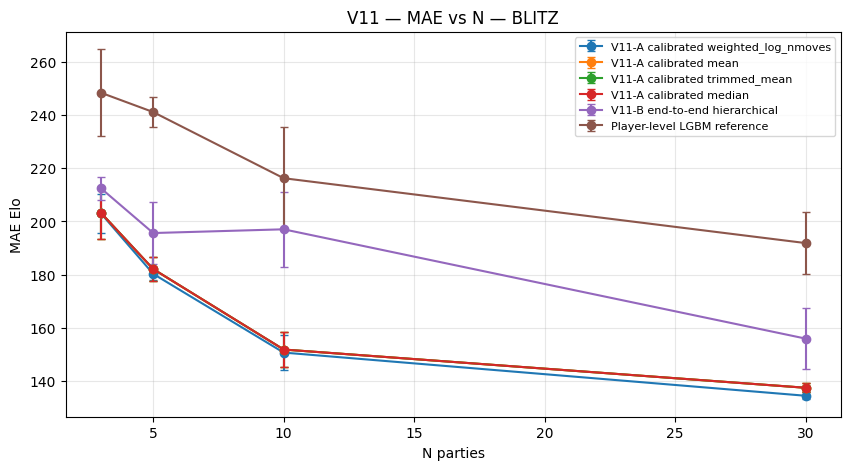

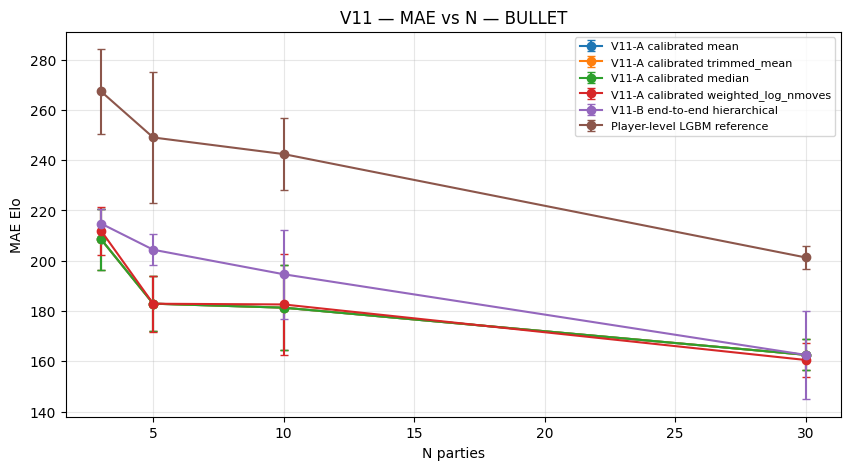

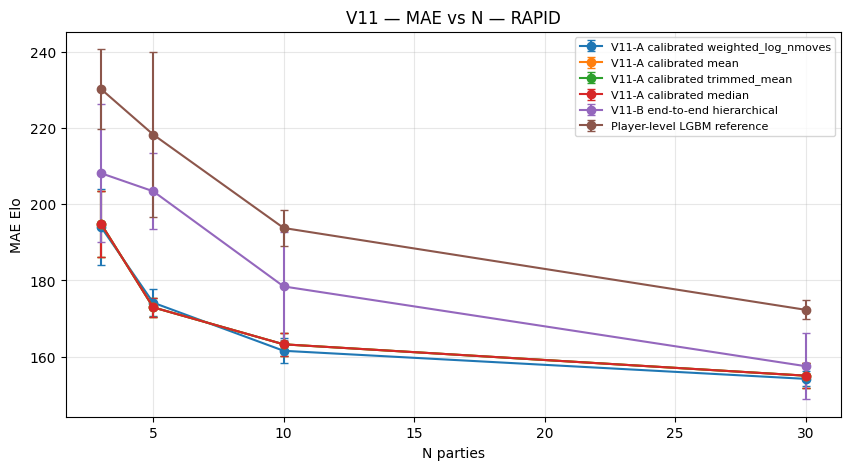

In [16]:
# ============================================================
# 9. Résumé et courbes
# ============================================================
v11_summary=(v11_results_df.groupby(["cadence","N","family","approach"]).agg(MAE_mean=("MAE","mean"),MAE_std=("MAE","std"),RMSE_mean=("RMSE","mean"),R2_mean=("R2","mean"),bias_mean=("bias","mean"),n_runs=("seed","count")).reset_index().sort_values(["cadence","N","MAE_mean"]))
v11_summary["MAE_display"]=v11_summary["MAE_mean"].round(1).astype(str)+" ± "+v11_summary["MAE_std"].round(1).astype(str)
display(v11_summary[["cadence","N","family","approach","MAE_display","R2_mean","bias_mean","n_runs"]])

best_v11=v11_summary.sort_values(["cadence","N","MAE_mean"]).groupby(["cadence","N"]).first().reset_index()
print("Best by cadence/N:")
display(best_v11[["cadence","N","family","approach","MAE_display","R2_mean","bias_mean"]])

for cad in sorted(v11_summary["cadence"].unique()):
    sub=v11_summary[v11_summary["cadence"]==cad]
    plt.figure(figsize=(10,5))
    for approach in sub["approach"].unique():
        if "raw" in approach: continue
        s=sub[sub["approach"]==approach].sort_values("N")
        plt.errorbar(s["N"],s["MAE_mean"],yerr=s["MAE_std"],marker="o",capsize=3,label=approach)
    plt.title(f"V11 — MAE vs N — {cad.upper()}"); plt.xlabel("N parties"); plt.ylabel("MAE Elo"); plt.grid(True,alpha=.3); plt.legend(fontsize=8); plt.show()


In [17]:
# ============================================================
# 10. Analyse par buckets Elo
# ============================================================
bucket_rows=[]
for key,dfp in V11_PRED_TABLES.items():
    cadence,N,seed,approach_key=key; df=dfp.copy()
    if "pred_player_elo" not in df.columns: continue
    df=add_elo_buckets(df,"elo",5); df["bias"]=df["pred_player_elo"]-df["elo"]; df["abs_error"]=np.abs(df["bias"])
    b=df.groupby("elo_bucket",observed=False).agg(elo_true_mean=("elo","mean"),pred_mean=("pred_player_elo","mean"),bias_mean=("bias","mean"),MAE=("abs_error","mean"),n=("elo","count")).reset_index()
    b["cadence"]=cadence; b["N"]=N; b["seed"]=seed; b["approach_key"]=approach_key; bucket_rows.append(b)
bucket_detail_df=pd.concat(bucket_rows,ignore_index=True) if bucket_rows else pd.DataFrame()
bucket_summary=(bucket_detail_df.groupby(["cadence","N","approach_key","elo_bucket"],observed=False).agg(elo_true_mean=("elo_true_mean","mean"),pred_mean=("pred_mean","mean"),bias_mean=("bias_mean","mean"),MAE=("MAE","mean"),n=("n","sum")).reset_index().sort_values(["cadence","N","approach_key","elo_bucket"]))
display(bucket_summary.head(80))


,cadence,N,approach_key,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
0,blitz,3,V11A_cal_mean,0,1217.678571,1528.698432,311.019861,320.622600,84
1,blitz,3,V11A_cal_mean,1,1496.964286,1596.757882,99.793596,156.158709,84
2,blitz,3,V11A_cal_mean,2,1669.797619,1664.912110,-4.885509,117.397880,84
3,blitz,3,V11A_cal_mean,3,1885.190476,1719.417061,-165.773415,185.594955,84
4,blitz,3,V11A_cal_mean,4,2072.797619,1840.317395,-232.480225,236.316223,84
...,...,...,...,...,...,...,...,...,...
75,blitz,5,V11A_raw_median,0,1224.059524,1556.485502,332.425978,332.425978,84
76,blitz,5,V11A_raw_median,1,1504.392857,1628.072369,123.679512,142.889453,84
77,blitz,5,V11A_raw_median,2,1667.654762,1687.603652,19.948890,89.507020,84
78,blitz,5,V11A_raw_median,3,1881.285714,1727.017784,-154.267930,161.118837,84


In [18]:
# ============================================================
# 11. Sauvegarde des résultats
# ============================================================
v11_results_path=CACHE_DIR/"v11_results_by_seed.csv"
v11_summary_path=CACHE_DIR/"v11_summary.csv"
bucket_summary_path=CACHE_DIR/"v11_bucket_summary.csv"
v11_results_df.to_csv(v11_results_path,index=False)
v11_summary.to_csv(v11_summary_path,index=False)
bucket_summary.to_csv(bucket_summary_path,index=False)
print("Saved:")
print(v11_results_path)
print(v11_summary_path)
print(bucket_summary_path)


Saved:
/content/_pmind_v11_cache/v11_results_by_seed.csv
/content/_pmind_v11_cache/v11_summary.csv
/content/_pmind_v11_cache/v11_bucket_summary.csv


# Notes d'interprétation

- **V11-A calibrated** teste si un embedding de partie appris depuis les coups améliore la stratégie V10 calibrée.
- **V11-B end-to-end** est plus ambitieux et plus risqué : s'il est moins bon, cela peut venir du faible nombre de joueurs et de l'overfitting.
- Compare toujours avec les vrais résultats V9/V10 calibrée de tes notebooks précédents : ce notebook donne une V11 complète, mais ton V9 original reste la référence exacte.
